# **Minimum Spanning Tree (MST) comparison between 3D and its 2D projection.** 

**Simplest example of how projection affects MST statistics.**

- Generates N random points uniformly within a 3D sphere (radius R).
- Optionally rotates the cloud (Euler angles) before projection.
- Projects to 2D by dropping the z-axis.
- Computes MST (Minimum Spanning Tree) in 3D and 2D.
- Compares edge sets and lengths; reports overlap metrics.
- Plots the 3D MST (perspective) and the 2D MST.
- Plots histograms of MST lengths in 3D and 2D.

Produces the following from Barnes et al. (2026): 

- **Fig B1**: Minimum spanning tree (MST) comparison for a uniform spherical distribution of N=200 points within radius R=1.0. Left: MST
network constructed in 3D. Middle: MST built from the projected 2D positions (no rotation). Right: Distributions of MST edge lengths in 3D
(blue) and 2D (orange), with medians (dashed lines) and kernel density estimates (KDEs) overplotted. The total MST length decreases from
38.4 (3D) to 16.1 (2D), corresponding to a mean ratio ⟨ℓ3D/ℓ2D⟩ ≃ 2.38, well above the geometric expectation (4/π) ≃ 1.27. Only ∼25% of
3D edges are recovered in 2D (Jaccard similarity 0.14), indicating that projection not only foreshortens MST edges but also rewires the network
topology—though less severely than for the nearest–neighbour (NN) graph (cf. Fig. 2).

In [ ]:
# Core scientific imports
import numpy as np
import matplotlib.pyplot as plt

# corespaceing3d imports
from corespaceing3d import main
from corespaceing3d.plotting import plot_3d, plot_2d, plot_length_histograms

In [2]:
# ------------------------- configuration -------------------------
N_POINTS = 200       # number of cores
RADIUS = 1.0         # sphere radius
SEED = 42            # RNG seed for reproducibility

# Rotation of the 3D clump *before* projecting to 2D
# (Right-handed, extrinsic rotations; order Z (alpha), Y (beta), X (gamma))
ALPHA_DEG = 0     # rotate about Z
BETA_DEG  = 0     # rotate about Y
GAMMA_DEG = 0     # rotate about X

# Toggle plotting
SHOW_PLOTS = True
# -----------------------------------------------------------------


NN comparison: 3D vs projected 2D
Sampling: N=200, R=1
Profile:  uniform (Uniform)
Rotation: α=0.0°, β=0.0°, γ=0.0° (extrinsic Z-Y-X)

Edge-set overlap
------------------------------------------------------------------------
Shared edges: 49 / 199
Only in 3D:  150
Only in 2D:  150
Overlap (3D→2D recovery): 0.246
Jaccard similarity:        0.140

Total NN length
------------------------------------------------------------------------
3D: 38.41400
2D: 16.13469

Mean edge-length ratio
------------------------------------------------------------------------
<l_2D>/<l_3D> = 0.420  (geometric expectation ≈ 0.785)

3D NN edge-length stats (N=199):
  mean=0.19304, median=0.19714, std=0.06241, mad=0.04356
  min=0.04724, p10=0.10502, p25=0.15261, p50=0.19714, p75=0.23917, p90=0.27075, p95=0.28364, p99=0.31865, max=0.34815

2D NN edge-length stats (N=199):
  mean=0.08108, median=0.08072, std=0.03995, mad=0.03090
  min=0.00312, p10=0.03143, p25=0.04884, p50=0.08072, p75=0.11020, p90=0.12855, p95=

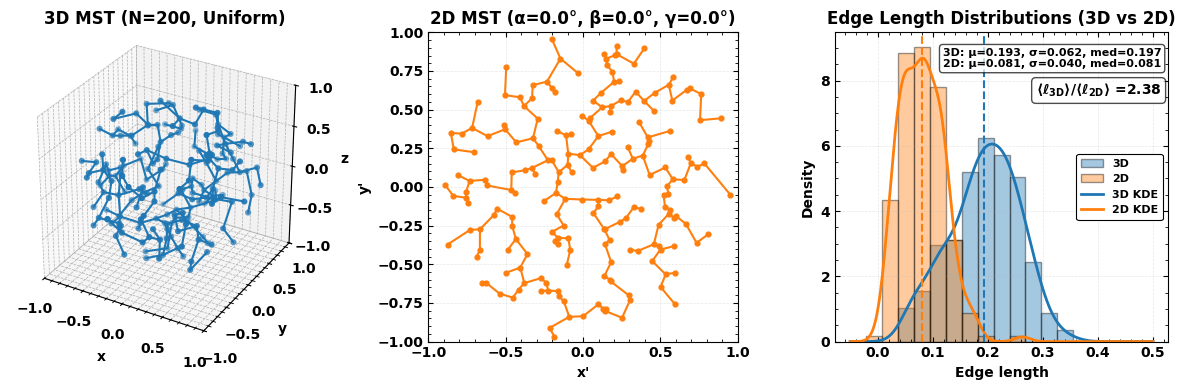

In [3]:
# Run the pipeline
profile = "uniform"

out = main(
    N_POINTS=N_POINTS,
    RADIUS=RADIUS,
    SEED=SEED,
    profile=profile,                 # or 'uniform','powerlaw','exponential','plummer','shell'
    ALPHA_DEG=ALPHA_DEG,
    BETA_DEG=BETA_DEG,
    GAMMA_DEG=GAMMA_DEG,
    verbose=True,
    method="mst"
)

# Unpack for plotting
pts3d_rot = out["pts3d_rot"]
pts2d     = out["pts2d"]
edges3d   = out["edges3d"]
edges2d   = out["edges2d"]
len3      = out["len3"]
len2      = out["len2"]
title3d   = out["titles"]["title3d"]
title2d   = out["titles"]["title2d"]

# 3-panel figure
fig = plt.figure(figsize=(12, 4))
ax3d   = fig.add_subplot(131, projection='3d')
ax2d   = fig.add_subplot(132)
axhist = fig.add_subplot(133)

plot_3d(ax3d, pts3d_rot, edges3d, title=title3d)
plot_2d(ax2d, pts2d, edges2d, title=title2d)
bins = np.linspace(-0.05, 0.5, 20)
plot_length_histograms(axhist, len3, len2, bins=bins)

fig.tight_layout()

fig.savefig(
    "./../figures/"
    f"mst_{profile}_N{N_POINTS}_R{RADIUS}"
    f"_a{ALPHA_DEG:.0f}_b{BETA_DEG:.0f}_g{GAMMA_DEG:.0f}.pdf",
    dpi=300, bbox_inches="tight"
)